In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id, google_folder_id2, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: d:\GMM 4\Reading seminar\Projet-recheche-INSA-anomaly-detection-librairy\src


In [ ]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)
list_keys = list(data_dict.keys())
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

Extracted data found at: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [ ]:
data_dict2, extracted_dir = load_data(
    file_id=google_folder_id2,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data2.tar",
    pattern="*.csv",
)

list_keys2 = list(data_dict2.keys())
list_session2 = []
for s in list_keys2:
    df = data_dict2[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session2.append(s)

Extracted data found at: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
Loading CAST data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24


In [ ]:
len(list_session)

40

In [ ]:
len(list_session2)

58

## Functions

In [ ]:
def visualisation_plot(df, cols, df2=None):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    if df2 is not None:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            visualisation.plot(df2, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_plot_nparray(df, array, cols, both=False):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    if both:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            ax.plot(df["time_real"].values, df[col].values)
            ax.plot(df["time_real"].values, array[:,cols.index(col)])
    else:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            ax.plot(df["time_real"].values, array[:,cols.index(col)])
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_anomalies(df, anomaly_mask, cols, method="pca", lag=8):
    """
    Visualize anomalies on the original signal

    Parameters
    ----------
    df : pandas DataFrame
        The original dataframe containing the signals and time
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    cols : list of str
        The list of columns to visualize

    Returns
    -------
    None
    """
    # Visualize anomalies
    dff = df.copy()
    if method == "dpca":
        dff = df.iloc[lag:,:].reset_index(drop=True)
    anomaly_times = dff.loc[anomaly_mask, 'time_real']

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()

    for ax, col in zip(axes, cols[:nrows * ncols]):

        # original signal plot
        visualisation.plot(dff, 'time_real', col, ax=ax)

        # overlay anomaly points
        ax.scatter(
            anomaly_times,
            dff.loc[anomaly_mask, col],
            color='red',
            s=10,
            label='SPE anomaly',
            zorder=3
        )

        ax.legend(loc="upper right", fontsize=8)

    # hide unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

def pca_anomaly_detection(df,cols, PCA, SCALER, seuil=None, d=3, method="SPE", clf_IF=None):
    """
    Apply PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    PCA : PCA object
        The trained PCA model
    SCALER : StandardScaler object
        The trained scaler used for PCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    res_pca = PCA.transform(df_center)
    if method == "SPE":
        res_pca[:,d:] = 0
        df_inv = PCA.inverse_transform(res_pca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_pca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

def dpca_anomaly_detection(df,cols, DPCA, SCALER, seuil=None, lag=8, d=3, method="SPE", clf_IF=None):
    """
    Apply dynamic PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    DPCA : PCA object
        The trained dynamic PCA model
    SCALER : StandardScaler object
        The trained scaler used for DPCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    df_center = dynamic_augmentation(df_center, s=lag)
    res_dpca = DPCA.transform(df_center)
    if method == "SPE":
        res_dpca[:,d:] = 0
        df_inv = DPCA.inverse_transform(res_dpca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_dpca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

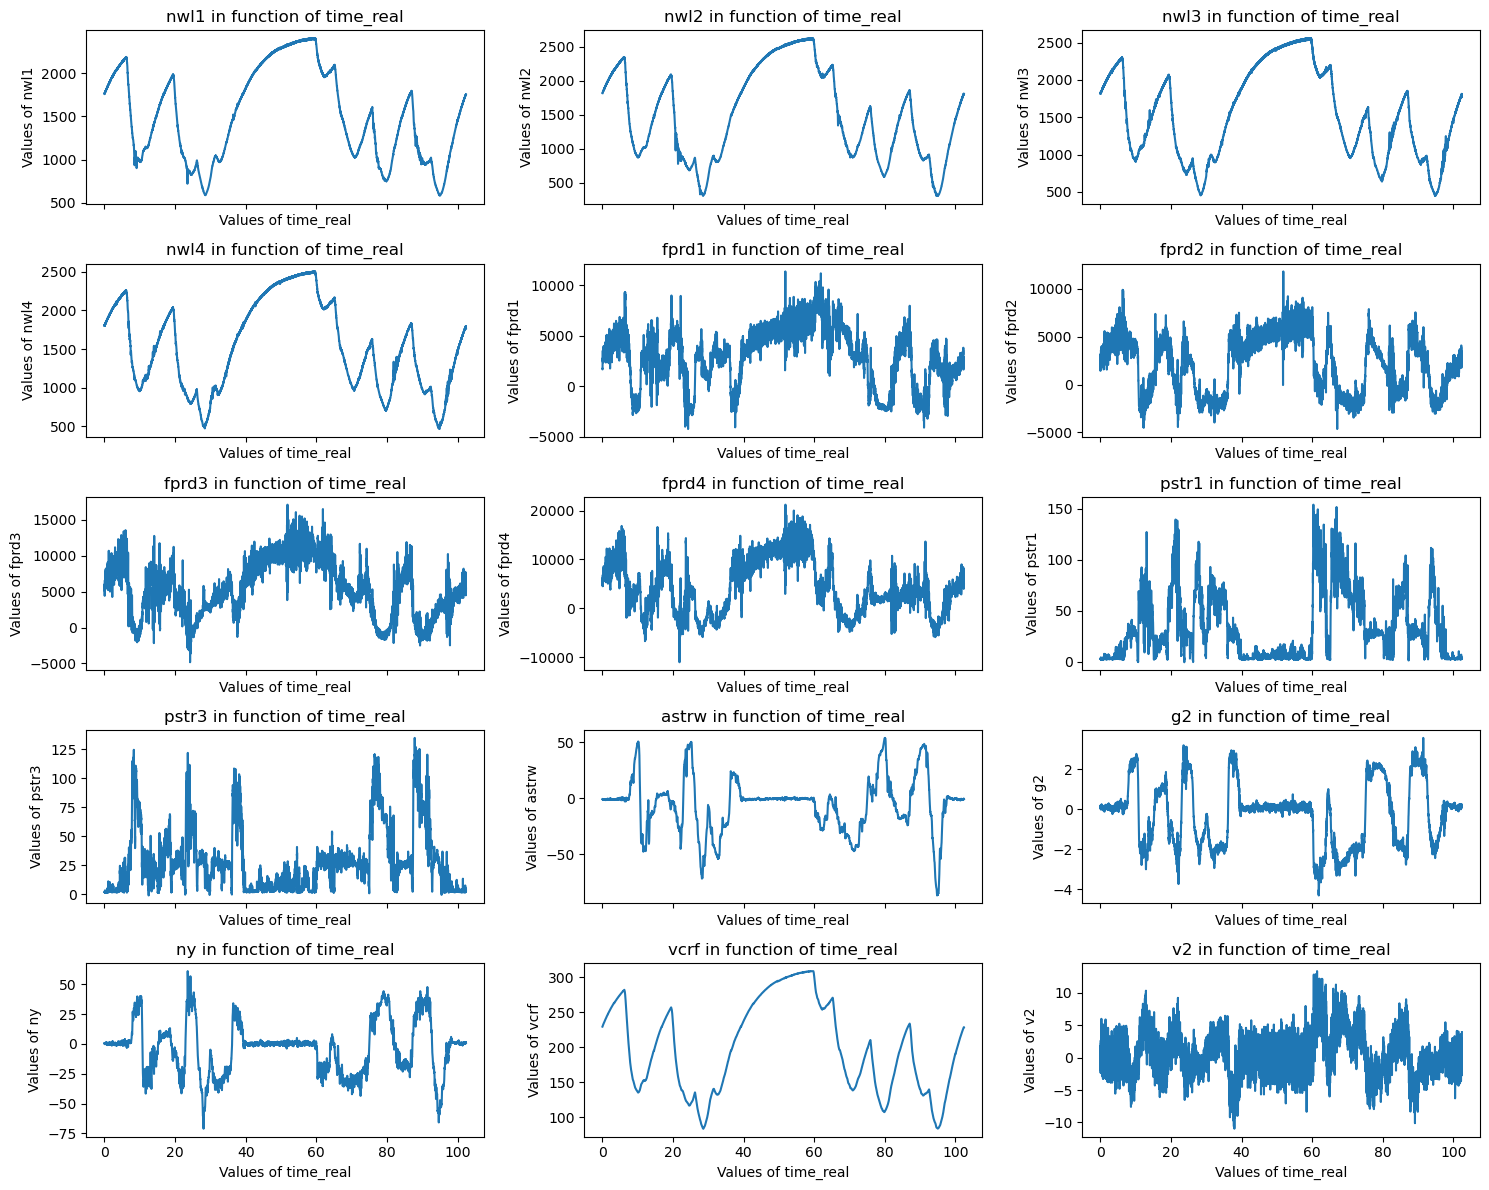

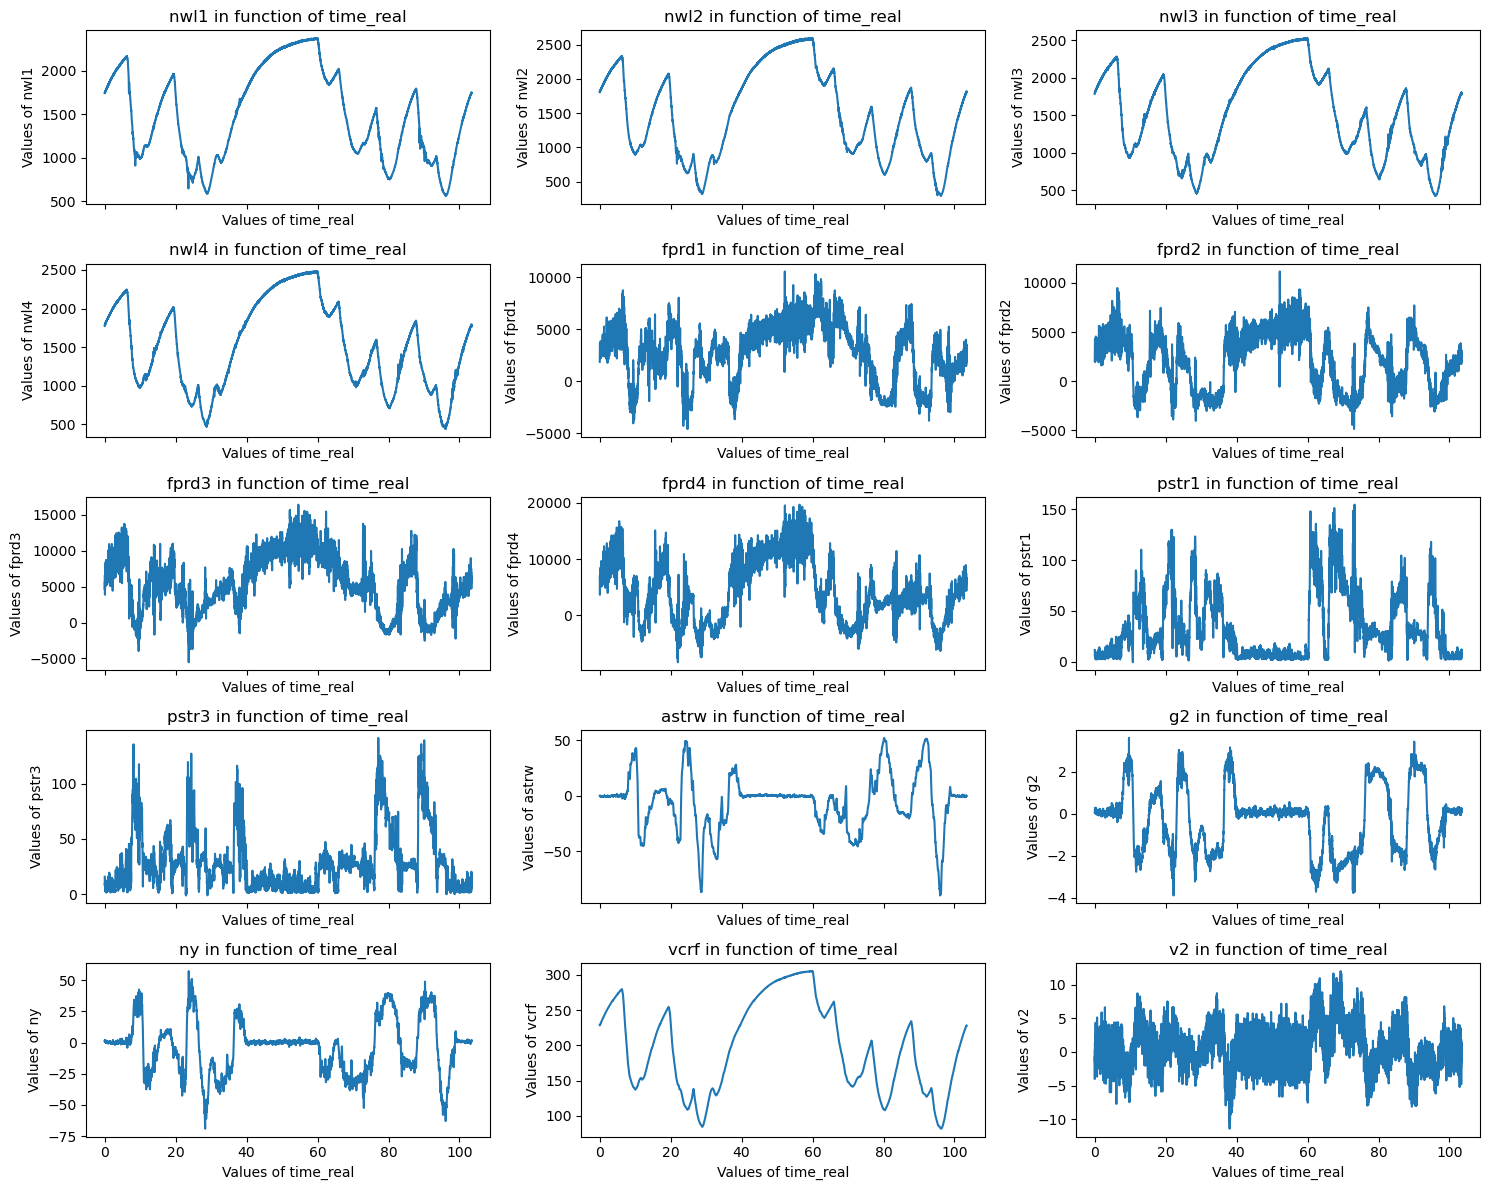

In [ ]:
# Visualize a session from the second dataset (maybe used for testing)
for s in list_session2[:2]:
    df = data_dict2[s].copy()
    df = preprocessing.clean_dataframe(df)
    cols = df.columns[1:-1]
    visualisation_plot(df, cols)

# Preparation

In [ ]:
from joblib import dump, load
from tensorflow.keras.models import load_model

In [ ]:
pca = load('./work01-data_exploration/models/pca_model.joblib')
if_pca = load('./work01-data_exploration/models/if_model.joblib')
dpca = load('./work01-data_exploration/models/dpca_model.joblib')
if_dy = load('./work01-data_exploration/models/if_dy_model.joblib')
mgkpca = load('./work01-data_exploration/models/mgkpca_model.joblib')
scaler = load('./work01-data_exploration/models/scaler_model.joblib')
GRU = load_model('./work01-data_exploration/models/DNN_autoencoder.keras')
scaler_GRU = load('./work01-data_exploration/models/scaler_DNN_autoencoder.pkl')

c:\Users\LT-MSI\.conda\envs\PI\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
temp_list = []

for path, df in data_dict2.items():
        # On extrait juste le nom du fichier
        clean_name = os.path.splitext(os.path.basename(path))[0]
        df_cleaned = preprocessing.clean_dataframe(df.copy())
        
        # C. Ajout de l'identifiant de session
        df_cleaned['session_id'] = clean_name
        
        # D. Stockage
        temp_list.append(df_cleaned)

In [ ]:
df_all2 = pd.concat(temp_list, ignore_index=True)
display(df_all2)

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-05-27 06:27:25.884,1758.07,1819.07,1818.91,1804.18,1716.18,2035.96,5739.03,5735.74,2.77914,1.70990,-0.767094,0.059888,0.753332,229.676,0.128456,0.00,T24S15-04_E-AL10009
1,2024-05-27 06:27:25.894,1756.17,1824.98,1820.00,1810.42,1689.52,1550.28,6016.73,6223.17,2.63348,2.09986,-0.856000,0.131166,0.753332,229.764,-0.657001,0.01,T24S15-04_E-AL10009
2,2024-05-27 06:27:25.904,1767.57,1822.61,1815.63,1798.98,1657.06,1430.88,5229.64,5694.56,2.76874,1.90488,-0.952988,0.131166,-0.039752,229.853,-1.096860,0.02,T24S15-04_E-AL10009
3,2024-05-27 06:27:25.914,1765.67,1822.61,1816.72,1801.06,1800.80,1958.29,5297.02,4946.26,2.76874,1.72073,-0.961070,0.083648,0.594715,230.030,1.793620,0.03,T24S15-04_E-AL10009
4,2024-05-27 06:27:25.924,1759.97,1826.16,1820.00,1809.38,2455.72,2698.98,6026.59,5200.27,2.62308,2.11070,-0.961070,0.178685,0.526737,230.207,1.416610,0.04,T24S15-04_E-AL10009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646123,2024-05-08 13:43:03.654,1749.93,1812.58,1819.84,1804.57,2888.85,2839.24,4740.07,5561.31,3.81659,3.29204,-1.011320,0.094867,1.828120,228.374,-0.280821,103.06,T24S15-04_E-AL9998
646124,2024-05-08 13:43:03.664,1749.93,1812.58,1807.82,1794.18,1934.87,2647.98,6061.19,6412.58,3.88943,2.07882,-0.865841,0.059228,1.114340,228.551,0.975911,103.07,T24S15-04_E-AL9998
646125,2024-05-08 13:43:03.674,1748.98,1817.30,1802.36,1786.90,2102.94,2602.77,6521.28,6522.41,2.45361,2.53378,-1.011320,0.237423,0.615833,228.728,-1.097700,103.08,T24S15-04_E-AL9998
646126,2024-05-08 13:43:03.684,1755.63,1816.12,1802.36,1792.10,2599.06,2428.89,5974.10,6561.33,2.69291,2.38212,-1.156810,0.189904,1.114340,228.816,0.975911,103.09,T24S15-04_E-AL9998


In [ ]:
cols = [c for c in df_all2.columns if c not in ['datetime','session_id', 'index', 'time_real']]

In [ ]:
df_all2['session_id'] = df_all2['session_id'].astype("category")
df_center = scaler.transform(df_all2[cols])

In [ ]:
respca = pca.transform(df_center)
reskpca = mgkpca.transform_batches(df_center)

Transforming batch 0:10000 / 646128
Transforming batch 10000:20000 / 646128
Transforming batch 20000:30000 / 646128
Transforming batch 30000:40000 / 646128
Transforming batch 40000:50000 / 646128
Transforming batch 50000:60000 / 646128
Transforming batch 60000:70000 / 646128
Transforming batch 70000:80000 / 646128
Transforming batch 80000:90000 / 646128
Transforming batch 90000:100000 / 646128
Transforming batch 100000:110000 / 646128
Transforming batch 110000:120000 / 646128
Transforming batch 120000:130000 / 646128
Transforming batch 130000:140000 / 646128
Transforming batch 140000:150000 / 646128
Transforming batch 150000:160000 / 646128
Transforming batch 160000:170000 / 646128
Transforming batch 170000:180000 / 646128
Transforming batch 180000:190000 / 646128
Transforming batch 190000:200000 / 646128
Transforming batch 200000:210000 / 646128
Transforming batch 210000:220000 / 646128
Transforming batch 220000:230000 / 646128
Transforming batch 230000:240000 / 646128
Transforming ba

In [ ]:
df_pca = pd.DataFrame({
    "PC1": respca[:,0],
    "PC2": respca[:,1],
    "session": df_all2["session_id"].values
})
df_kpca = pd.DataFrame({
    "PC1": reskpca[:,0],
    "PC2": reskpca[:,1],
    "session": df_all2["session_id"].values
})

In [ ]:
centroid_pca = df_pca.groupby("session")[["PC1","PC2"]].mean()
centroid_kpca = df_kpca.groupby("session")[["PC1","PC2"]].mean()

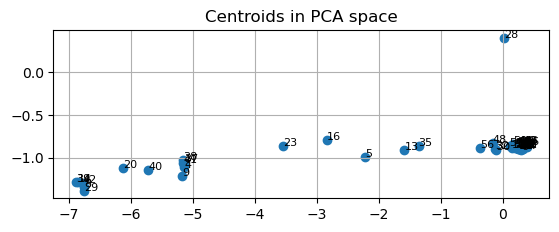

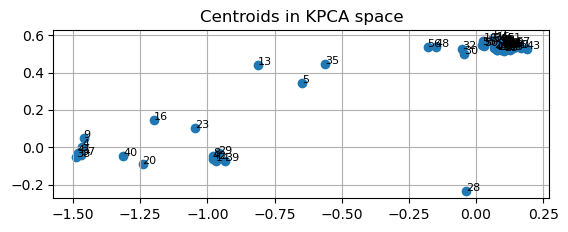

In [ ]:
plt.subplot(2, 1, 1)
plt.scatter(centroid_pca["PC1"],centroid_pca["PC2"])
for i, (idx, row) in enumerate(centroid_pca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)
plt.grid()
plt.title("Centroids in PCA space")
plt.show()
plt.subplot(2, 1, 2)
plt.scatter(centroid_kpca["PC1"],centroid_kpca["PC2"])
for i, (idx, row) in enumerate(centroid_kpca.iterrows()):
    plt.text(row["PC1"], row["PC2"], i, fontsize=8)
plt.grid()
plt.title("Centroids in KPCA space")
plt.show()

In [ ]:
# df contains:
# PC1, PC2, session

def build_session_features(df):
    features = []

    for session_id, g in df.groupby("session"):
        x = g["PC1"].values
        y = g["PC2"].values

        # basic stats
        mean_pc1 = np.mean(x)
        mean_pc2 = np.mean(y)

        std_pc1 = np.std(x, ddof=1) if len(x) > 1 else 0.0
        std_pc2 = np.std(y, ddof=1) if len(y) > 1 else 0.0

        var_pc1 = np.var(x, ddof=1) if len(x) > 1 else 0.0
        var_pc2 = np.var(y, ddof=1) if len(y) > 1 else 0.0

        cov_pc1_pc2 = np.cov(x, y, ddof=1)[0, 1] if len(x) > 1 else 0.0

        # range
        min_pc1 = np.min(x)
        max_pc1 = np.max(x)
        min_pc2 = np.min(y)
        max_pc2 = np.max(y)

        range_pc1 = max_pc1 - min_pc1
        range_pc2 = max_pc2 - min_pc2

        # number of samples in the session
        n_points = len(g)

        # optional: radius around centroid
        dist_to_centroid = np.sqrt((x - mean_pc1)**2 + (y - mean_pc2)**2)
        mean_radius = np.mean(dist_to_centroid)
        max_radius = np.max(dist_to_centroid)

        features.append({
            "session": session_id,
            "mean_pc1": mean_pc1,
            "mean_pc2": mean_pc2,
            "std_pc1": std_pc1,
            "std_pc2": std_pc2,
            "var_pc1": var_pc1,
            "var_pc2": var_pc2,
            "cov_pc1_pc2": cov_pc1_pc2,
            "range_pc1": range_pc1,
            "range_pc2": range_pc2,
            "mean_radius": mean_radius,
            "max_radius": max_radius,
            "n_points": n_points
        })

    return pd.DataFrame(features)

In [ ]:
session_features_pca = build_session_features(df_pca)
session_features_kpca = build_session_features(df_kpca)

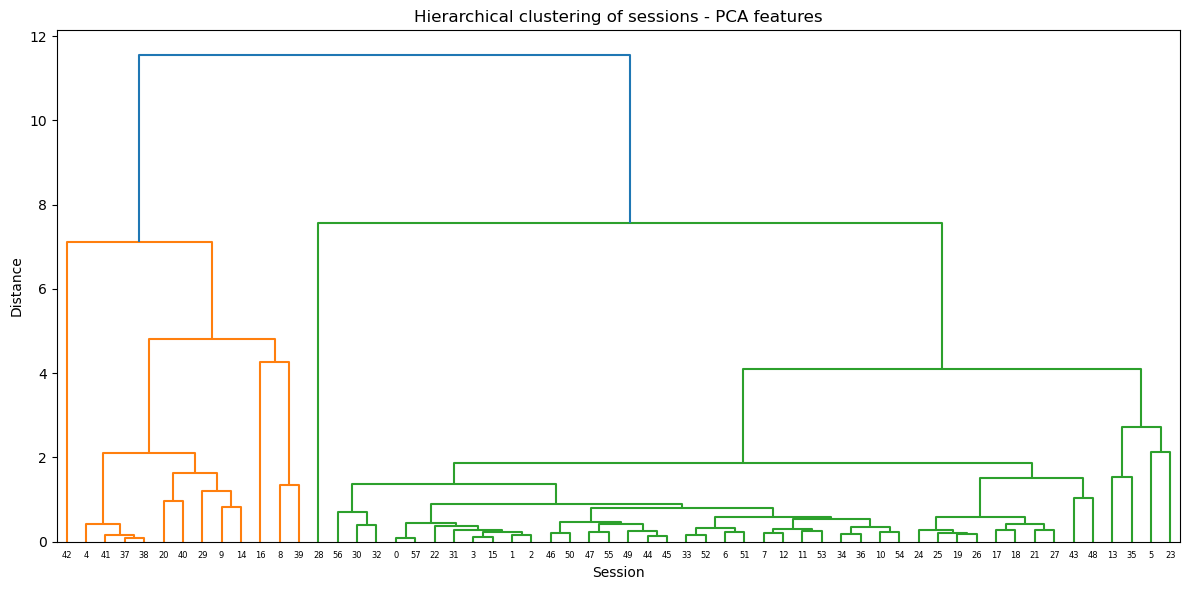

In [ ]:
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
feature_cols = [
    "mean_pc1", "mean_pc2",
    "std_pc1", "std_pc2",
    "var_pc1", "var_pc2",
    "cov_pc1_pc2",
    "range_pc1", "range_pc2",
    "mean_radius", "max_radius",
    "n_points"
]

X_session = session_features_pca[feature_cols].values
scalerF = StandardScaler()
X_session_scaled = scalerF.fit_transform(X_session)
Z = sch.linkage(X_session_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))
sch.dendrogram(
    Z,
    leaf_rotation=0
)
plt.title("Hierarchical clustering of sessions - PCA features")
plt.xlabel("Session")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

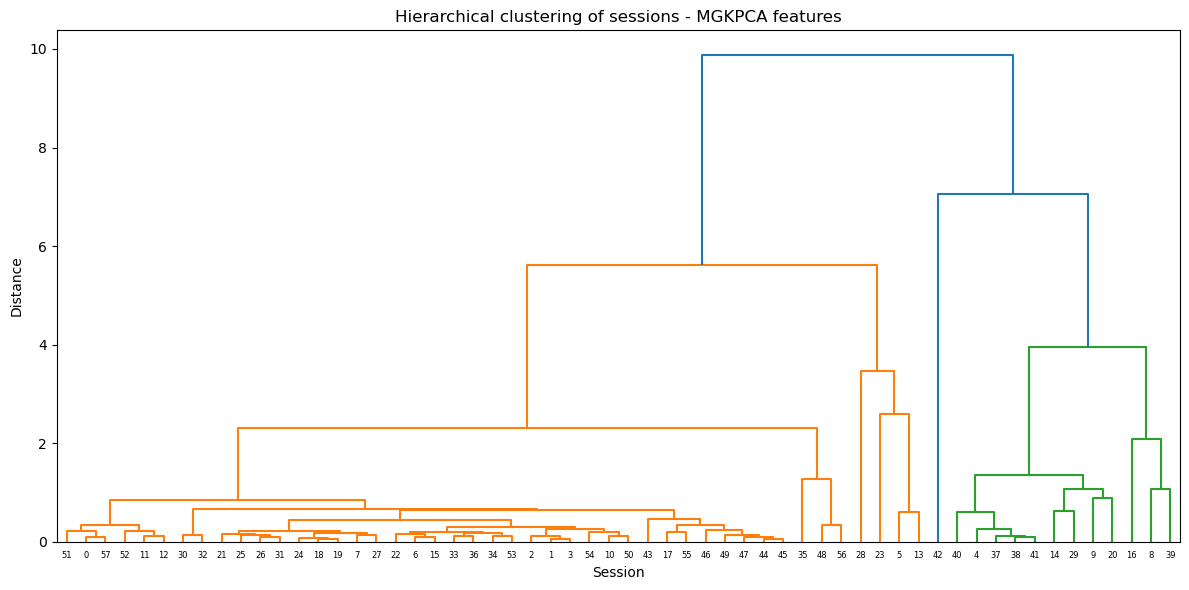

In [ ]:
X_session = session_features_kpca[feature_cols].values
scalerF = StandardScaler()
X_session_scaled = scalerF.fit_transform(X_session)
Z = sch.linkage(X_session_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))
sch.dendrogram(
    Z,
    leaf_rotation=0
)
plt.title("Hierarchical clustering of sessions - MGKPCA features")
plt.xlabel("Session")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**Comments**
- Border sessions : 35, 48, 56, 28, 23, 5, 13, 43, 30, 32
- To verify : 48, 43, 30, 32

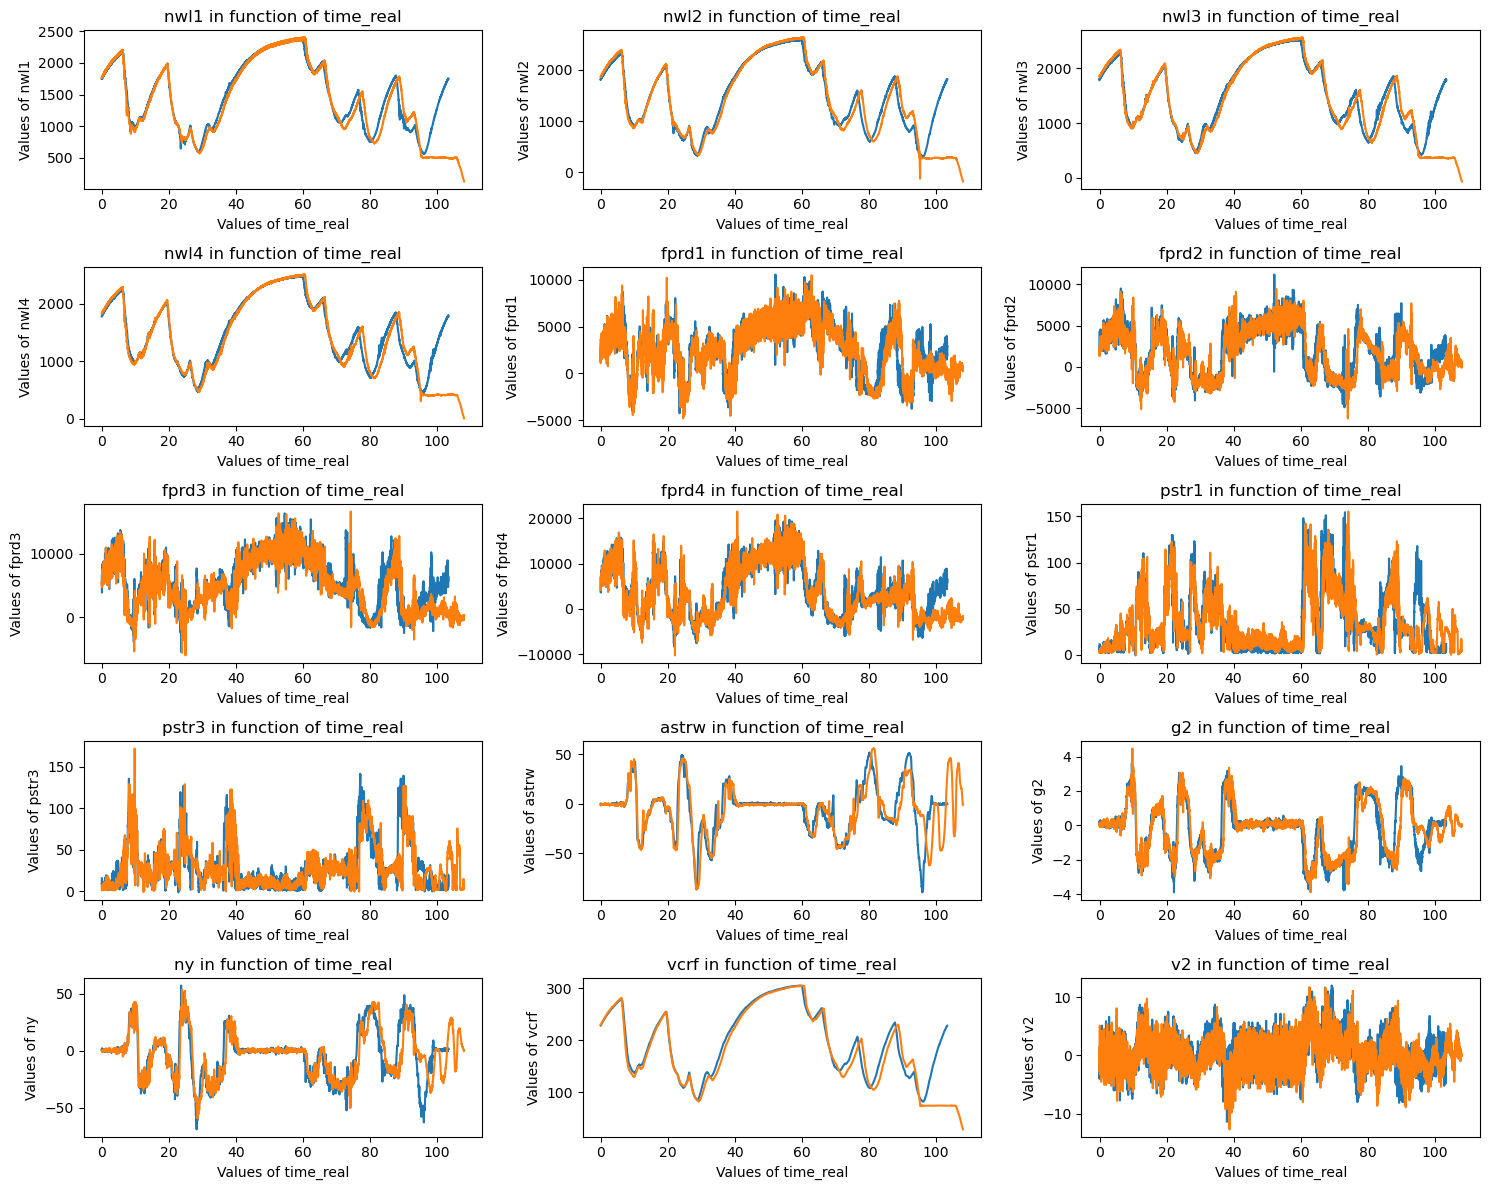

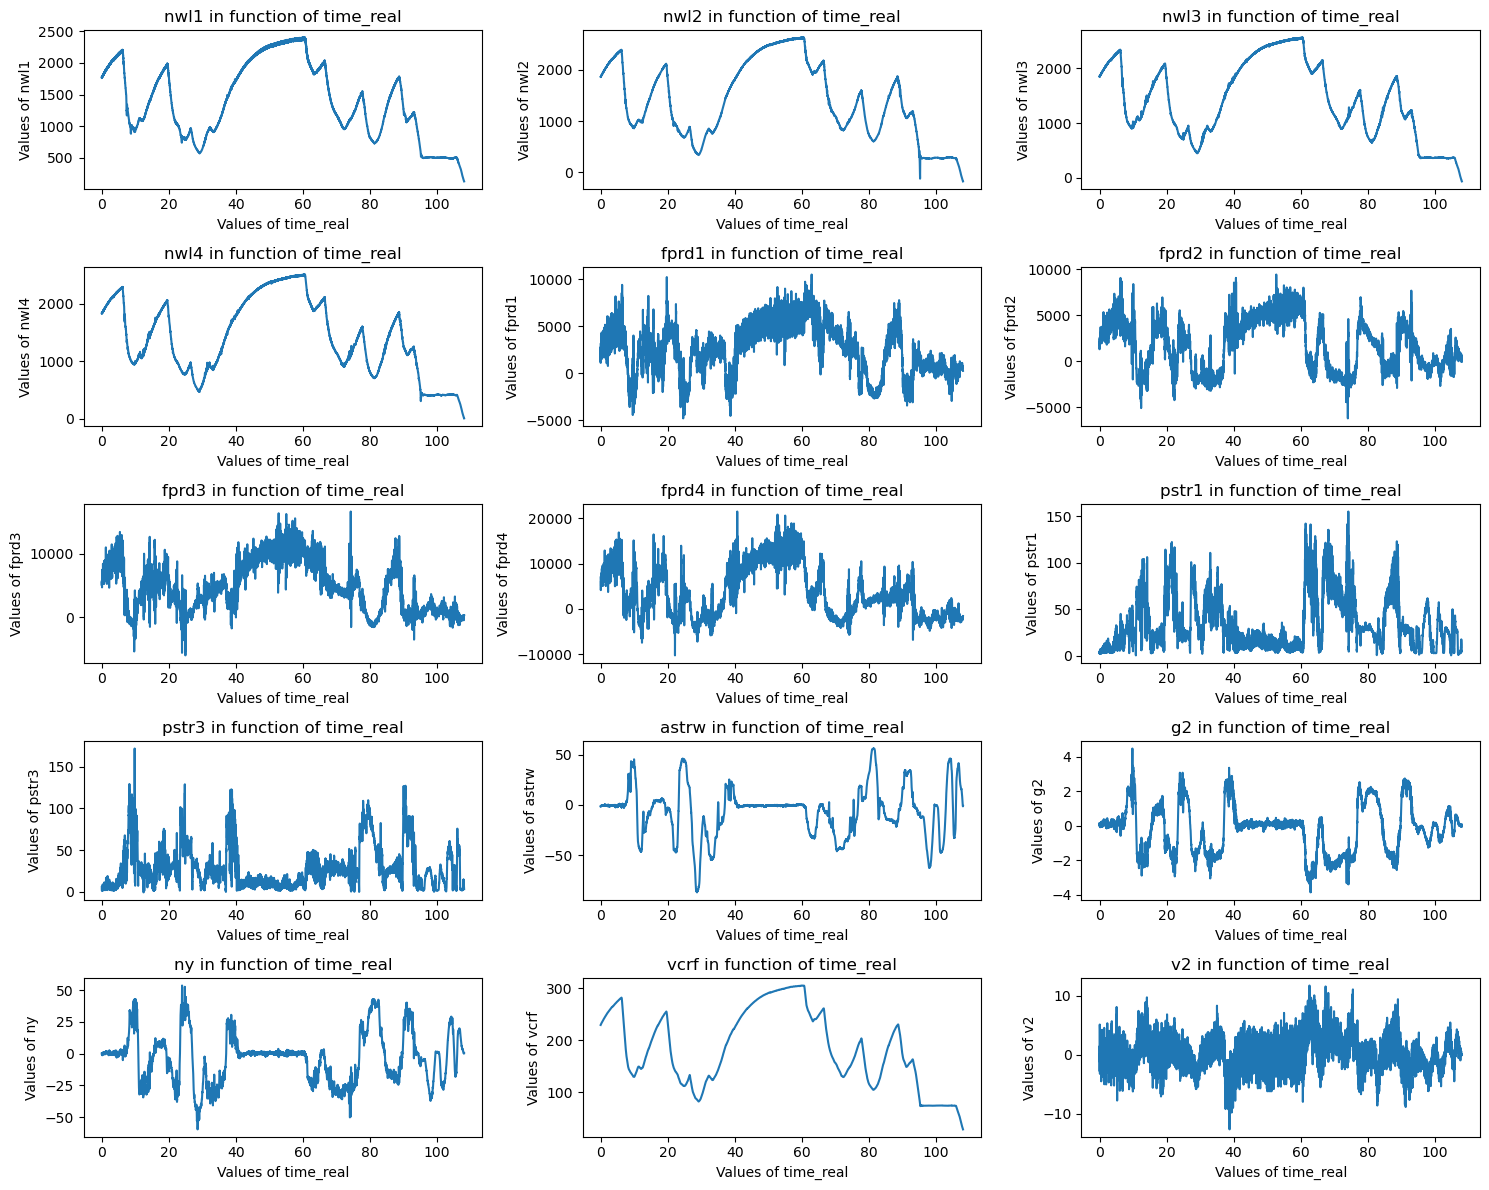

In [62]:
df = data_dict2[list_session2[1]].copy() # Normal
df2 = data_dict2[list_session2[32]].copy() # anomalous
df = preprocessing.clean_dataframe(df)
df2 = preprocessing.clean_dataframe(df2)
visualisation_plot(df, cols, df2)
visualisation_plot(df2,cols)